# SceneSage – Frame‑Aware Trailer Recommender

End‑to‑end baseline pipeline:
1. **Load** MP4 trailers & caption files (`.srt`).
2. **Extract** one frame per second (FFmpeg).
3. **Encode** each frame with OpenCLIP and the nearest caption with Sentence‑Transformers.
4. **Combine** image ⊕ text vectors and **index** them with FAISS.
5. **Demo** a similarity search that returns the most‑similar frames.

# 0 – install libraries (first run only)

In [1]:
# !pip -q install open-clip-torch sentence-transformers faiss-cpu ffmpeg-python opencv-python tqdm

# 1 – config paths

In [2]:
from pathlib import Path

ROOT      = Path('.')
VID_DIR   = ROOT / 'data/raw/videos'
CAP_DIR   = ROOT / 'data/raw/captions'
FRAME_DIR = ROOT / 'data/frames'
FRAME_DIR.mkdir(parents=True, exist_ok=True)

### Helper – pick the best English caption file

In [3]:
def caption_path_for(video_id: str):
    """Return Path to preferred English captions, else None."""
    from pathlib import Path
    preferred = CAP_DIR / f"{video_id}.en.srt"
    if preferred.exists():
        return preferred
    fallback = list(CAP_DIR.glob(f"{video_id}.en*.srt"))
    return fallback[0] if fallback else None

### 2 – Extract 1 frame / s per trailer

In [4]:
import os, subprocess, textwrap

# Point to your local ffmpeg install if it's not already on PATH.
# Example (Windows, installed via winget):
#   ffmpeg_dir = r"C:\path\to\ffmpeg\bin"
#   os.environ["PATH"] += ";" + ffmpeg_dir

# sanity-check
out = subprocess.run(["ffmpeg", "-version"], capture_output=True, text=True)
print(textwrap.shorten(out.stdout.splitlines()[0], width=80))


ffmpeg version 7.1.1-full_build-www.gyan.dev Copyright (c) 2000-2025 the [...]


In [5]:
import ffmpeg
import cv2, math, subprocess, shutil, numpy as np, tqdm
from pathlib import Path

def _ffmpeg_ok() -> bool:
    """Return True if ffmpeg is callable inside this kernel."""
    return shutil.which("ffmpeg") is not None

def extract_frames(video_path: Path, fps: int = 1, force_ffmpeg=False):
    """Save one JPG per `fps` to data/frames/<video_id>/000001.jpg …"""
    dest_dir = FRAME_DIR / video_path.stem
    dest_dir.mkdir(exist_ok=True)

    # Skip if already extracted
    if any(dest_dir.glob("*.jpg")):
        return dest_dir

    if force_ffmpeg or _ffmpeg_ok():
        try:
            (
                ffmpeg
                .input(str(video_path))
                .filter("fps", fps=fps)
                .output(str(dest_dir / "%06d.jpg"),
                        vsync="vfr", start_number=0)
                .overwrite_output()
                .run(capture_stdout=True, capture_stderr=True, quiet=True)
            )
            # verify at least one frame
            if any(dest_dir.glob("*.jpg")):
                return dest_dir
            print(f"[ffmpeg] no frames written for {video_path.name}, falling back...")
        except ffmpeg.Error as e:
            print(f"[ffmpeg] error on {video_path.name}:")
            print(e.stderr.decode()[:400], "...\nfalling back to OpenCV.")

    # ── fallback: OpenCV ───────────────────────────────────────────────
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"cannot open {video_path}")

    native_fps = cap.get(cv2.CAP_PROP_FPS) or 25
    step = int(round(native_fps / fps))
    frame_i = 0
    saved = 0
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) / step + 1)

    with tqdm.tqdm(total=total_frames, desc=f"OpenCV {video_path.stem}", unit="frm") as pbar:
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            if frame_i % step == 0:
                out = dest_dir / f"{saved:06d}.jpg"
                cv2.imwrite(str(out), frame)
                saved += 1
                pbar.update(1)
            frame_i += 1
    cap.release()
    return dest_dir




In [6]:
vid_files = sorted(VID_DIR.glob("*.mp4"))


In [7]:
# for vf in tqdm.tqdm(vid_files, desc="extract"):
#     extract_frames(vf, fps=1)    # add force_ffmpeg=True to bypass OpenCV fallback

### 3 – Set up encoders

In [8]:
import open_clip, torch
from PIL import Image
from sentence_transformers import SentenceTransformer
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)
clip_model, _, clip_pre = open_clip.create_model_and_transforms('ViT-B-32-quickgelu', pretrained='openai')
clip_model.eval().to(device)
txt_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)


cuda


In [9]:
import re, pathlib
_time_re = re.compile(r'(\d{2}):(\d{2}):(\d{2}),(\d{3})')

def _t2s(t: str):
    m = _time_re.match(t)
    if not m:                       # malformed timestamp
        return None
    h, mnt, s, ms = map(int, m.groups())
    return h*3600 + mnt*60 + s + ms/1000

def load_captions(path: pathlib.Path | None):
    """
    Return a list of (mid_time_sec, text) tuples.
    Silently skips any block that lacks a valid timestamp line.
    """
    if not path or not path.exists():
        return []

    pairs, block = [], []
    with open(path, encoding='utf-8', errors='ignore') as f:
        for line in f:
            if line.strip() == '' and block:
                if len(block) >= 3:                     # id, timestamp, text…
                    start_end = block[1].split(' --> ')
                    if len(start_end) == 2:
                        t0, t1 = map(_t2s, start_end)
                        if t0 is not None and t1 is not None:
                            mid = (t0 + t1) / 2
                            text = ' '.join(block[2:]).strip()
                            pairs.append((mid, text))
                block = []
            else:
                block.append(line.strip())
    return pairs

In [11]:
from pathlib import Path
from PIL import Image
import torch, open_clip, numpy as np, math, tqdm
from sentence_transformers import SentenceTransformer
from torch.utils.data import Dataset, DataLoader

device = "cuda"
BATCH_IMG = 256             # RTX 4070 8 GB handles 256 fp16 images easily
NUM_WORKERS = 8             # adjust to CPU cores

# --- models ------------------------------------------------------------
clip_model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32-quickgelu", pretrained="openai"
)
clip_model = clip_model.to(device).half().eval()

txt_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)

# --- dataset -----------------------------------------------------------
class FrameSample:
    def __init__(self, img_path: Path, caption: str, vid: str):
        self.img_path, self.caption, self.vid = img_path, caption, vid

class FrameDataset(Dataset):
    def __init__(self, samples, preprocess):
        self.samples = samples
        self.pre = preprocess

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        img = Image.open(s.img_path).convert("RGB")
        return self.pre(img).half(), s.caption, s.vid, s.img_path.name

# gather samples list (reuse your load_captions & caption_path_for) -----
samples = []
for vf in tqdm.tqdm(vid_files, desc="scan"):
    vid  = vf.stem
    caps = load_captions(caption_path_for(vid))
    t_arr= np.array([t for t,_ in caps]) if caps else np.array([])
    for fp in (FRAME_DIR/vid).glob("*.jpg"):
        sec  = int(fp.stem)
        text = ""
        if t_arr.size:
            text = caps[np.argmin(np.abs(t_arr-sec))][1]
        samples.append(FrameSample(fp, text, vid))

print("Frames:", len(samples))   # 50 021

# --- encode ------------------------------------------------------------
dataset = FrameDataset(samples, preprocess)
loader  = DataLoader(
    dataset,
    batch_size     = BATCH_IMG,
    num_workers    = 0,          # ← single-process
    pin_memory     = True,
    shuffle        = False
)


all_vecs, meta = [], []

for imgs, texts, vids, fnames in tqdm.tqdm(loader, desc="encode"):
    imgs = imgs.to(device, non_blocking=True)
    with torch.no_grad():
        v_img = clip_model.encode_image(imgs)          # GPU fp16 tensor

    # ---- text (GPU) ----
    v_txt = txt_model.encode(
        list(texts),
        device=device,
        convert_to_tensor=True,       # stay on GPU
        batch_size=BATCH_IMG,
        show_progress_bar=False,
    ).half()                          # (B,384) fp16

    # ---- concat on GPU, copy ONCE to host ----
    concat = torch.cat([v_img, v_txt], dim=1).cpu().numpy()
    all_vecs.append(concat)
    meta.extend(zip(vids, fnames))


vec_mat = np.vstack(all_vecs).astype("float32")
print("Final vec matrix:", vec_mat.shape)


scan: 100%|██████████| 348/348 [00:01<00:00, 288.27it/s]


Frames: 50021


encode: 100%|██████████| 196/196 [32:14<00:00,  9.87s/it] 

Final vec matrix: (50021, 896)


In [12]:
import numpy as np, pickle, faiss, pathlib, os

SAVE_DIR = pathlib.Path("artifacts")
SAVE_DIR.mkdir(exist_ok=True)

# 1) raw vectors  (≈ 50021 × 896 float32  ≈ 171 MB)
vec_path = SAVE_DIR / "frame_vectors.npy"
np.save(vec_path, vec_mat)
print("saved vectors  ➜", vec_path, vec_mat.shape)

# 2) metadata  (list of tuples, a few MB)
meta_path = SAVE_DIR / "frame_meta.pkl"
with open(meta_path, "wb") as f:
    pickle.dump(meta, f)
print("saved meta     ➜", meta_path, len(meta), "entries")

# 3) optional – FAISS cosine-similarity index
index = faiss.IndexFlatIP(vec_mat.shape[1])
faiss.normalize_L2(vec_mat)          # cosine via dot-product trick
index.add(vec_mat)
index_path = SAVE_DIR / "scene_index.faiss"
faiss.write_index(index, str(index_path))
print("saved faiss    ➜", index_path, f"{index.ntotal:,} vectors")


saved vectors  ➜ artifacts\frame_vectors.npy (50021, 896)
saved meta     ➜ artifacts\frame_meta.pkl 50021 entries
saved faiss    ➜ artifacts\scene_index.faiss 50,021 vectors


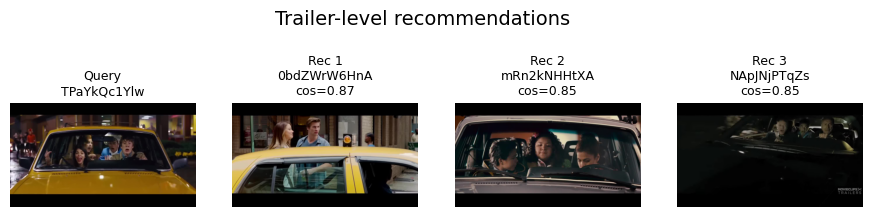

0bdZWrW6HnA → data\raw\videos\0bdZWrW6HnA.mp4
mRn2kNHHtXA → data\raw\videos\mRn2kNHHtXA.mp4
NApJNjPTqZs → data\raw\videos\NApJNjPTqZs.mp4


In [14]:
import random, numpy as np, matplotlib.pyplot as plt, matplotlib.gridspec as gs
from PIL import Image
from pathlib import Path

# ── paths ───────────────────────────────────────────
FRAME_DIR = Path("data/frames")
VIDEO_DIR = Path("data/raw/videos")      # MP4 files (optional)

# ── 1. pick a random query frame ────────────────────
q_idx       = random.randrange(len(vec_mat))
q_vec       = vec_mat[q_idx:q_idx+1].copy()
faiss.normalize_L2(q_vec)                # cosine-norm just like index

query_vid, query_fname = meta[q_idx]     # trailer ID of query

# ── 2. search top-N similar frames ──────────────────
N_NEIGH = 50
D, I = index.search(q_vec, N_NEIGH)

# ── 3. harvest first frame per *different* trailer ──
k          = 3                           # trailers to recommend
seen_vids  = {query_vid}
picks      = []                          # (vid, frame_path, score)

for rank, idx in enumerate(I[0]):
    vid, fname = meta[idx]
    if vid in seen_vids:                 # skip query trailer & dupes
        continue
    picks.append((vid, fname, D[0][rank]))
    seen_vids.add(vid)
    if len(picks) == k:
        break

# ── 4. visualise: query + 3 trailer reps ───────────
plt.figure(figsize=(11,3))
grid = gs.GridSpec(1, k+1)

# show query frame
plt.subplot(grid[0]); 
plt.imshow(Image.open(FRAME_DIR/query_vid/query_fname)); 
plt.axis('off'); plt.title("Query\n"+query_vid, fontsize=9)

# show one rep frame for each recommended trailer
for col, (vid, fname, score) in enumerate(picks, 1):
    img = Image.open(FRAME_DIR/vid/fname)
    plt.subplot(grid[col])
    plt.imshow(img); plt.axis('off')
    plt.title(f"Rec {col}\n{vid}\ncos={score:.2f}", fontsize=9)

plt.suptitle("Trailer-level recommendations", fontsize=14)
plt.show()

# optional: path to full trailer MP4 for later use
for vid, _, _ in picks:
    mp4_path = VIDEO_DIR / f"{vid}.mp4"
    print(vid, "→", mp4_path)


In [21]:
# ▣ 0  Imports & device
import subprocess, tempfile, shutil, faiss, numpy as np, torch, os
from pathlib import Path
from collections import Counter
from tqdm.auto import tqdm
from PIL import Image
import open_clip                                   # vision encoder

device      = "cuda"                               # GPU
BATCH       = 256                                  # RTX-4070 (8 GB) sweet spot
k_search    = 50                                   # neighbours per frame
k_rec_each  = 3                                    # keep this many uniq trailers / frame
topN        = 3                                    # final trailers returned

# ▣ 1  Load or reuse CLIP model & transforms  (fp16 on GPU)
clip_model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32-quickgelu", pretrained="openai"
)
clip_model = clip_model.to(device).half().eval()

# ▣ 2  Load pre-computed reference data  (edit paths if different)
ART        = Path("artifacts")
vec_mat    = np.load(ART/"frame_vectors.npy")            # (N, 896) float32
with open(ART/"frame_meta.pkl","rb") as f: meta = pickle.load(f)
index      = faiss.read_index(str(ART/"scene_index.faiss"))

# ▣ 3  Helpers ----------------------------------------------------------
def _extract_tmp_frames(mp4_path: Path, fps: int = 1) -> Path:
    tmp = Path(tempfile.mkdtemp())
    cmd = ["ffmpeg","-v","error","-i",str(mp4_path),
           "-vf",f"fps={fps}", str(tmp/"%06d.jpg")]
    subprocess.run(cmd, check=True)
    return tmp

# ---- inside _encode_frames -------------------------------------------
@torch.no_grad()
def _encode_frames(frame_dir: Path):
    jpgs  = sorted(frame_dir.glob("*.jpg"))
    out   = []
    zero384 = np.zeros(384, dtype="float32")

    for i in range(0, len(jpgs), BATCH):
        batch_files = jpgs[i:i+BATCH]
        imgs = [preprocess(Image.open(p).convert("RGB")).half() for p in batch_files]
        imgs = torch.stack(imgs).to(device, non_blocking=True)

        v_img = clip_model.encode_image(imgs).cpu().numpy().astype("float32")
        faiss.normalize_L2(v_img)

        # ---- pad with zeros so dim = 512+384 = 896 ----
        v_full = np.hstack([v_img, np.tile(zero384, (v_img.shape[0], 1))])
        out.append(v_full)

    return np.ascontiguousarray(np.vstack(out), dtype="float32")

def recommend_trailers_for_mp4(mp4_path, top_n=topN, fps=1):
    mp4_path = Path(mp4_path)
    tmp      = _extract_tmp_frames(mp4_path, fps)
    try:
        q_vecs = _encode_frames(tmp)          # (F, 512)
    finally:
        shutil.rmtree(tmp, ignore_errors=True)

    votes, scores = Counter(), {}
    D, I = index.search(q_vecs, k_search)

    for row in range(len(q_vecs)):
        seen = set()                          # per-frame dedup
        for col in I[row]:
            vid, _ = meta[col]
            if vid not in seen:
                votes[vid] += 1
                scores.setdefault(vid, []).append(D[row][np.where(I[row]==col)[0][0]])
                seen.add(vid)
                if len(seen) == k_rec_each:
                    break

    ranked = [(v, votes[v], float(np.mean(scores[v]))) for v in votes]
    ranked.sort(key=lambda x: (-x[1], -x[2]))
    return ranked[:top_n]

# ▣ 4  Example call on *one* of your dataset trailers
VIDEO_DIR  = Path("data/raw/videos")
query_mp4  = next(VIDEO_DIR.glob("*.mp4"))        # first trailer in folder
print("Query:", query_mp4.name)

best = recommend_trailers_for_mp4(query_mp4, top_n=3, fps=1)
for vid, cnt, cos in best:
    print(f"{vid:15s}  votes={cnt:<4d}  mean_cos={cos:.3f}")


Query: 07XbSk7Rjt4.mp4
07XbSk7Rjt4      votes=60    mean_cos=0.996
g7Xn2JqH5ng      votes=29    mean_cos=0.841
4Zl7S1LaPMU      votes=11    mean_cos=0.996


In [24]:
from pathlib import Path

VIDEO_DIR  = Path("data/raw/videos")
query_mp4  = VIDEO_DIR / "GSmJ5UXtUnk.mp4"   # <-- Path, not string
print("Query:", query_mp4.name)

best = recommend_trailers_for_mp4(query_mp4, top_n=3, fps=1)
for vid, cnt, cos in best:
    print(f"{vid:15s}  votes={cnt:<4d}  mean_cos={cos:.3f}")


Query: GSmJ5UXtUnk.mp4
GSmJ5UXtUnk      votes=1404  mean_cos=0.963
jcdhyaP0T7g      votes=498   mean_cos=0.868
OwlynHlZEc4      votes=289   mean_cos=0.885
